# BERT Fine-Tuning — Hands-On Project
### Sentiment Classification with `bert-base-uncased` on IMDB

**Goal:** Fine-tune a pretrained BERT model on a real classification task (positive/negative movie review sentiment).

**What you'll learn / do:**
1. Load and inspect a real dataset (IMDB reviews)
2. Tokenize text using BERT's WordPiece tokenizer
3. Load `BertForSequenceClassification` with a classification head
4. Fine-tune using Hugging Face `Trainer`
5. Evaluate with accuracy/F1 and run live inference

**Runtime:** Go to `Runtime > Change runtime type > GPU (T4)` before starting.

## 1. Install Dependencies

In [3]:
!pip install -q transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00


## 2. Imports & GPU Check

In [4]:
import torch
import numpy as np
from datasets import load_dataset
from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
import evaluate

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type != "cuda":
    print("WARNING: No GPU detected. Go to Runtime > Change runtime type > GPU.")

Using device: cuda


## 3. Load Dataset

We use the IMDB movie review dataset (25k train / 25k test, binary sentiment).
For a **fast classroom demo**, we subsample to a few thousand examples. Increase `TRAIN_SIZE` / `TEST_SIZE` for a fuller run.

`https://huggingface.co/datasets/stanfordnlp/imdb`

In [5]:
raw_dataset = load_dataset("stanfordnlp/imdb")

TRAIN_SIZE = 3000   # increase for better accuracy, decrease for a faster demo
TEST_SIZE = 1000

train_dataset = raw_dataset["train"].shuffle(seed=42).select(range(TRAIN_SIZE))
test_dataset  = raw_dataset["test"].shuffle(seed=42).select(range(TEST_SIZE))

print(train_dataset)
print(train_dataset[0])

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label'],
    num_rows: 3000
})
{'text': 'There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier\'s plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot similarities... The main character is weak and weirdo, but have "clairvoyance". People like to compare, to judge, to evaluate. How about just enjoying? Funny thing too, people writing Fortier looks American but, on the other hand, arguing they prefer American series (!!!). Maybe it\'s the language, or the spirit, but I think this series is more English than American. By the way, the actors are really good and funny. The acting is not superficial at all...', 'label': 1}


## Exploratory Data Analysis

In [6]:
# ========== EDA IMPORTS ==========
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from collections import Counter
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
# Set style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [7]:
# ========== 1. BASIC DATASET INFO ==========
print("\n=== DATASET OVERVIEW ===")
print(f"Training set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")
print(f"Label distribution in train:\n{pd.Series(train_dataset['label']).value_counts().sort_index()}")
print(f"Label distribution in test:\n{pd.Series(test_dataset['label']).value_counts().sort_index()}")


=== DATASET OVERVIEW ===
Training set size: 3000
Test set size: 1000
Label distribution in train:
0    1511
1    1489
Name: count, dtype: int64
Label distribution in test:
0    512
1    488
Name: count, dtype: int64


In [8]:
# ========== 2. TEXT LENGTH ANALYSIS ==========
# Compute text length in words for raw dataset
train_texts = train_dataset['text']
test_texts = test_dataset['text']

train_word_counts = [len(text.split()) for text in train_texts]
test_word_counts = [len(text.split()) for text in test_texts]

# Create DataFrame for plotting
df_train = pd.DataFrame({
    'word_count': train_word_counts,
    'label': train_dataset['label']
})
df_test = pd.DataFrame({
    'word_count': test_word_counts,
    'label': test_dataset['label']
})

# Interactive histogram with Plotly
fig1 = make_subplots(rows=1, cols=2, subplot_titles=('Train Set', 'Test Set'))
fig1.add_trace(go.Histogram(x=df_train['word_count'], nbinsx=50, name='Train'), row=1, col=1)
fig1.add_trace(go.Histogram(x=df_test['word_count'], nbinsx=50, name='Test'), row=1, col=2)
fig1.update_layout(title_text='Distribution of Review Length (Number of Words)', showlegend=False)
fig1.show()

# Boxplot by sentiment
fig2 = px.box(df_train, x='label', y='word_count', color='label',
              title='Review Length by Sentiment (Train)',
              labels={'label': 'Sentiment (0=Neg, 1=Pos)', 'word_count': 'Word Count'})
fig2.show()


## 4. Tokenization

In [9]:
MODEL_NAME = "bert-base-uncased"
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=256)

train_tokenized = train_dataset.map(tokenize_fn, batched=True)
test_tokenized  = test_dataset.map(tokenize_fn, batched=True)

# Rename label column to match Trainer's expectations and set format
train_tokenized = train_tokenized.rename_column("label", "labels")
test_tokenized  = test_tokenized.rename_column("label", "labels")

columns = ["input_ids", "attention_mask", "labels"]
train_tokenized.set_format(type="torch", columns=columns)
test_tokenized.set_format(type="torch", columns=columns)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [10]:
import datasets.config
datasets.config.TORCHVISION_AVAILABLE = False

# ========== 3. TOKENIZED LENGTH DISTRIBUTION ==========
# Use the tokenized dataset
token_lengths_train = [len(x['input_ids']) for x in train_tokenized]
token_lengths_test = [len(x['input_ids']) for x in test_tokenized]

fig3 = make_subplots(rows=1, cols=2, subplot_titles=('Train Tokens', 'Test Tokens'))
fig3.add_trace(go.Histogram(x=token_lengths_train, nbinsx=50, name='Train'), row=1, col=1)
fig3.add_trace(go.Histogram(x=token_lengths_test, nbinsx=50, name='Test'), row=1, col=2)
fig3.update_layout(title_text='Distribution of Tokenized Length (after truncation at 256)', showlegend=False)
fig3.show()

In [11]:
# Check how many reviews are truncated (max length = 256)
truncated_train = sum(1 for l in token_lengths_train if l == 256)
truncated_test = sum(1 for l in token_lengths_test if l == 256)
print(f"\nReviews truncated at max_length (256) in train: {truncated_train}/{len(train_tokenized)} ({truncated_train/len(train_tokenized)*100:.1f}%)")
print(f"Reviews truncated in test: {truncated_test}/{len(test_tokenized)} ({truncated_test/len(test_tokenized)*100:.1f}%)")


Reviews truncated at max_length (256) in train: 1319/3000 (44.0%)
Reviews truncated in test: 403/1000 (40.3%)


In [12]:
# ========== 4. MOST COMMON WORDS ==========
def get_common_words(texts, n=20, remove_stopwords=True):
    from nltk.corpus import stopwords
    import nltk
    nltk.download('stopwords', quiet=True)
    stop_words = set(stopwords.words('english'))
    words = []
    for text in texts:
        words.extend(text.lower().split())
    if remove_stopwords:
        words = [w for w in words if w not in stop_words and w.isalpha()]
    return Counter(words).most_common(n)

# Overall common words in train
common_train = get_common_words(train_texts, n=20)
common_neg = get_common_words([train_texts[i] for i, l in enumerate(train_dataset['label']) if l == 0], n=20)
common_pos = get_common_words([train_texts[i] for i, l in enumerate(train_dataset['label']) if l == 1], n=20)

print("\n=== TOP 20 WORDS (Overall) ===")
for word, count in common_train:
    print(f"{word}: {count}")

# Bar chart for overall top words
words, counts = zip(*common_train)
fig4 = px.bar(x=list(words), y=list(counts), title='Top 20 Most Frequent Words (Train)',
              labels={'x': 'Word', 'y': 'Frequency'})
fig4.show()


=== TOP 20 WORDS (Overall) ===
movie: 3812
film: 3340
one: 2753
like: 2285
would: 1498
even: 1494
good: 1430
really: 1328
see: 1229
get: 1035
much: 1028
story: 987
also: 960
make: 955
people: 934
great: 915
time: 915
first: 900
could: 900
made: 862


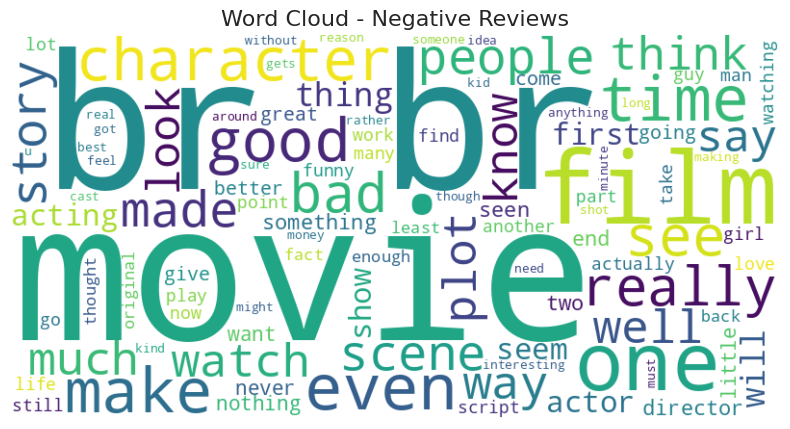

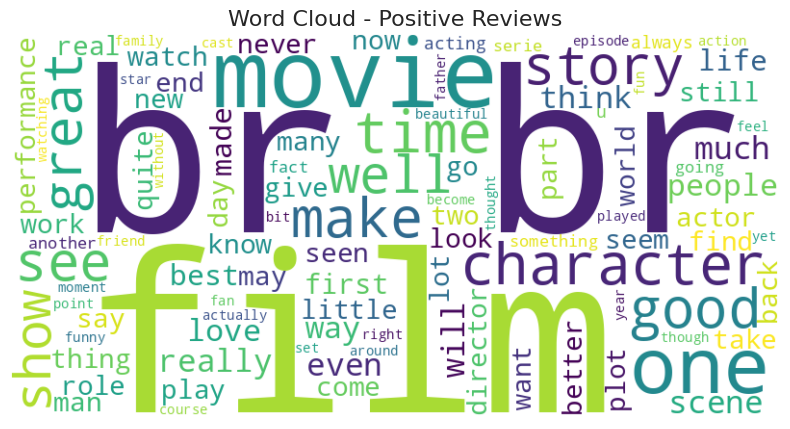

In [13]:
# ========== 5. WORD CLOUDS (by sentiment) ==========
def generate_wordcloud(texts, title):
    text_combined = ' '.join(texts)
    wordcloud = WordCloud(width=800, height=400, background_color='white',
                          colormap='viridis', max_words=100).generate(text_combined)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=16)
    plt.axis('off')
    plt.show()
# Generate word clouds for positive and negative reviews
neg_texts = [train_texts[i] for i, l in enumerate(train_dataset['label']) if l == 0]
pos_texts = [train_texts[i] for i, l in enumerate(train_dataset['label']) if l == 1]
generate_wordcloud(neg_texts, 'Word Cloud - Negative Reviews')
generate_wordcloud(pos_texts, 'Word Cloud - Positive Reviews')

In [14]:
# ========== 6. SAMPLE REVIEWS ==========
print("\n=== SAMPLE REVIEWS ===")
for label, name in [(0, 'Negative'), (1, 'Positive')]:
    sample_idx = [i for i, l in enumerate(train_dataset['label']) if l == label][0]
    print(f"\n--- {name} Review (Train) ---")
    print(train_dataset[sample_idx]['text'][:500] + "...\n")


=== SAMPLE REVIEWS ===

--- Negative Review (Train) ---
George P. Cosmatos' "Rambo: First Blood Part II" is pure wish-fulfillment. The United States clearly didn't win the war in Vietnam. They caused damage to this country beyond the imaginable and this movie continues the fairy story of the oh-so innocent soldiers. The only bad guys were the leaders of the nation, who made this war happen. The character of Rambo is perfect to notice this. He is extremely patriotic, bemoans that US-Americans didn't appreciate and celebrate the achievements of the sin...


--- Positive Review (Train) ---
There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot similarities... The main character is weak and weirdo, but have "clairvoyance". People like to compare, t

In [15]:
# ========== 7. DATA QUALITY CHECKS ==========
print("\n=== DATA QUALITY ===")
# Check for empty reviews
empty_train = sum(1 for text in train_texts if len(text.strip()) == 0)
empty_test = sum(1 for text in test_texts if len(text.strip()) == 0)
print(f"Empty reviews in train: {empty_train}")
print(f"Empty reviews in test: {empty_test}")

# Check for duplicate reviews (simplistic)
unique_train = len(set(train_texts))
unique_test = len(set(test_texts))
print(f"Unique reviews in train: {unique_train}/{len(train_texts)} ({unique_train/len(train_texts)*100:.1f}%)")
print(f"Unique reviews in test: {unique_test}/{len(test_texts)} ({unique_test/len(test_texts)*100:.1f}%)")


=== DATA QUALITY ===
Empty reviews in train: 0
Empty reviews in test: 0
Unique reviews in train: 3000/3000 (100.0%)
Unique reviews in test: 1000/1000 (100.0%)


In [16]:
# ========== 8. SUMMARY STATISTICS ==========
print("\n=== SUMMARY STATISTICS ===")
print(f"Average word count (train): {np.mean(train_word_counts):.1f} (±{np.std(train_word_counts):.1f})")
print(f"Average word count (test):  {np.mean(test_word_counts):.1f} (±{np.std(test_word_counts):.1f})")
print(f"Average token length (train): {np.mean(token_lengths_train):.1f} (±{np.std(token_lengths_train):.1f})")
print(f"Average token length (test):  {np.mean(token_lengths_test):.1f} (±{np.std(token_lengths_test):.1f})")


=== SUMMARY STATISTICS ===
Average word count (train): 230.8 (±169.3)
Average word count (test):  215.3 (±150.9)
Average token length (train): 207.1 (±57.5)
Average token length (test):  203.2 (±58.7)


## 5. Load Pretrained BERT with a Classification Head

In [17]:
model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(device)
print(model.config)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.12.1",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}



## 6. Define Evaluation Metrics

In [18]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels)
    return {"accuracy": acc["accuracy"], "f1": f1["f1"]}

## 7. Training Arguments & Trainer

In [19]:
training_args = TrainingArguments(
    output_dir="./bert-imdb-checkpoints",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=25,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none",
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

## 8. Fine-Tune the Model

In [20]:
import datasets.config
datasets.config.TORCHVISION_AVAILABLE = False

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.326364,0.303291,0.873000,0.873632
2,0.226003,0.314425,0.878000,0.878486


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=376, training_loss=0.3063463416505367, metrics={'train_runtime': 103.9938, 'train_samples_per_second': 57.696, 'train_steps_per_second': 3.616, 'total_flos': 789333166080000.0, 'train_loss': 0.3063463416505367, 'epoch': 2.0})

## 9. Evaluate on Test Set

In [21]:
metrics = trainer.evaluate()
print(metrics)

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.226003,0.314425,2,0.878000,0.878486


{'eval_loss': 0.3144252300262451, 'eval_accuracy': 0.878, 'eval_f1': 0.8784860557768924}


## 10. Save the Fine-Tuned Model

In [22]:
SAVE_DIR = "./bert-imdb-finetuned"
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"Model saved to {SAVE_DIR}")

# Optional: zip and download to your machine
# !zip -r bert-imdb-finetuned.zip ./bert-imdb-finetuned
# from google.colab import files
# files.download("bert-imdb-finetuned.zip")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./bert-imdb-finetuned


## 11. Run Inference on New Sentences

In [23]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model=SAVE_DIR,
    tokenizer=SAVE_DIR,
    device=0 if torch.cuda.is_available() else -1,
)

sample_reviews = [
    "This movie was absolutely wonderful, the acting blew me away!",
    "Waste of two hours. Terrible plot and awful dialogue.",
    "It was okay, not the best but not the worst either.",
]

for review in sample_reviews:
    result = classifier(review)[0]
    label = "POSITIVE" if result["label"] == "LABEL_1" else "NEGATIVE"
    print(f"{review}\n -> {label} (score={result['score']:.3f})\n")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

This movie was absolutely wonderful, the acting blew me away!
 -> POSITIVE (score=0.967)

Waste of two hours. Terrible plot and awful dialogue.
 -> NEGATIVE (score=0.986)

It was okay, not the best but not the worst either.
 -> POSITIVE (score=0.702)



In [24]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model=SAVE_DIR,
    tokenizer=SAVE_DIR,
    device=0 if torch.cuda.is_available() else -1,
)

sample_reviews = [
    "A beautiful woman, a backwoods, inbred monster man, a super sweet monster truck, a road kill zombie brother and 2 friends...one anal retentive, overly sensitive nerd and the other a foul mouthed, adolescent slob. Throw them all together with a dash of Jeepers Creepers, Texas Chainsaw Massacre and Road Trip and you've got Monster Man. A hilarious horror/comedy outing that never sets out to say something. It's a simple, straight forward laugh fest. Unpretentious and well made, this horror/comedy is at its heart, a buddy flick. This film offered some hilarious and sickening set pieces. I highly recommend this to fright fans looking to be entertained.",
    "This was some what good movie but some scenes are very rarely fear to me",
    "I had high hopes for this one until they changed the name to 'The Shepherd : Border Patrol, the lamest movie name ever, what was wrong with just 'The Shepherd'. This is a by the numbers action flick that tips its hat at many classic Van Damme films. There is a nice bit of action in a bar which reminded me of hard target and universal soldier but directed with no intensity or flair which is a shame. There is one great line about 'being p*ss drunk and carrying a rabbit' and some OK action scenes let down by the cheapness of it all. A lot of the times the dialogue doesn't match the characters mouth and the stunt men fall down dead a split second before even being shot. The end fight is one of the better Van Damme fights except the Director tries to go a bit too John Woo and fails also introducing flashbacks which no one really cares about just gets in the way of the action which is the whole point of a van Damme film.<br /><br />Not good, not bad, just average generic action.",
]

for review in sample_reviews:
    result = classifier(review)[0]
    label = "POSITIVE" if result["label"] == "LABEL_1" else "NEGATIVE"
    print(f"{review}\n -> {label} (score={result['score']:.3f})\n")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

A beautiful woman, a backwoods, inbred monster man, a super sweet monster truck, a road kill zombie brother and 2 friends...one anal retentive, overly sensitive nerd and the other a foul mouthed, adolescent slob. Throw them all together with a dash of Jeepers Creepers, Texas Chainsaw Massacre and Road Trip and you've got Monster Man. A hilarious horror/comedy outing that never sets out to say something. It's a simple, straight forward laugh fest. Unpretentious and well made, this horror/comedy is at its heart, a buddy flick. This film offered some hilarious and sickening set pieces. I highly recommend this to fright fans looking to be entertained.
 -> POSITIVE (score=0.974)

This was some what good movie but some scenes are very rarely fear to me
 -> POSITIVE (score=0.922)

I had high hopes for this one until they changed the name to 'The Shepherd : Border Patrol, the lamest movie name ever, what was wrong with just 'The Shepherd'. This is a by the numbers action flick that tips its ha